In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.animation as animation
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from tqdm import tqdm
from PIL import Image
import os
import gc
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

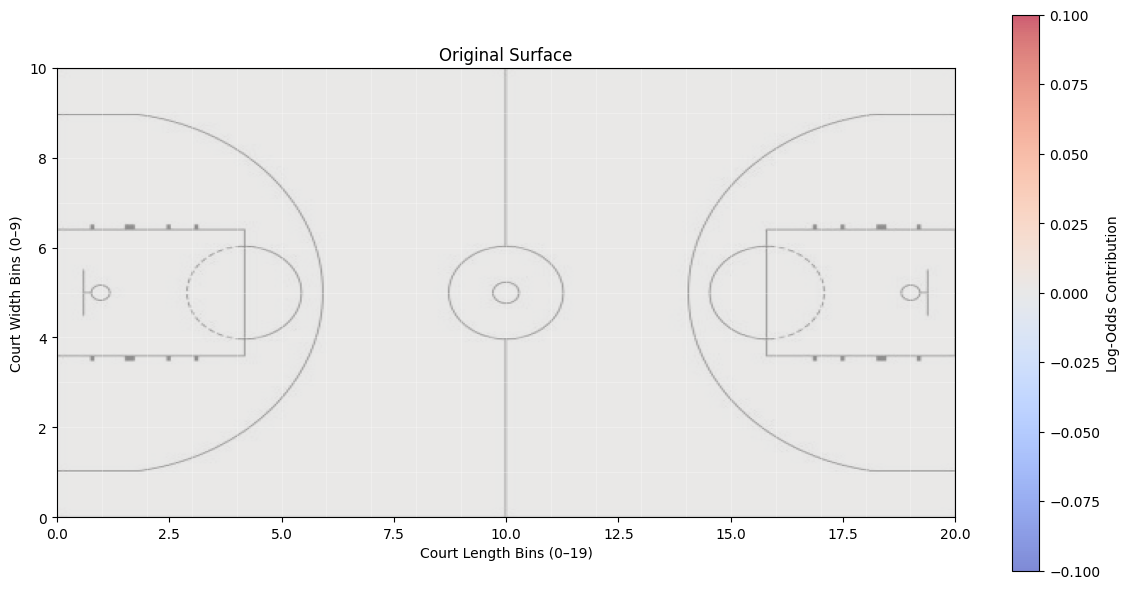

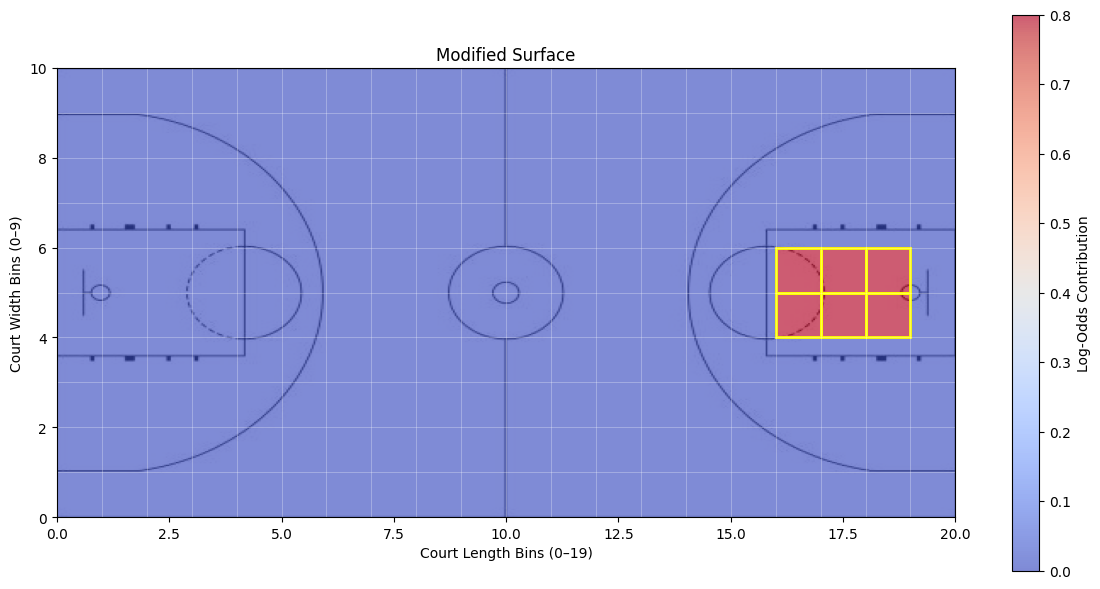

In [37]:
# -------------------------------------------------
# COURT SETTINGS
# -------------------------------------------------

x_bins = 20
y_bins = 10

court_img = Image.open("court.jpg")

# -------------------------------------------------
# 1. CREATE BLANK LOG-ODDS MATRIX
# -------------------------------------------------

# Each cell represents a sector's contribution to scoring log-odds
propensity_matrix = np.zeros((x_bins, y_bins))

# -------------------------------------------------
# 2. FUNCTION TO MODIFY SECTORS
# -------------------------------------------------

def build_range_updates(length_range, width_range, value):
    x_start, x_end = length_range
    y_start, y_end = width_range

    return {
        (x, y): value
        for x in range(x_start, x_end + 1)
        for y in range(y_start, y_end + 1)
    }


def adjust_sector_propensity(matrix, updates, mode="add"):
    
    new_matrix = matrix.copy()

    for (x, y), value in updates.items():

        if mode == "add":
            new_matrix[x, y] += value

        elif mode == "set":
            new_matrix[x, y] = value

        else:
            raise ValueError("mode must be 'add' or 'set'")

    return new_matrix


# -------------------------------------------------
# 3. PLOT FUNCTION
# -------------------------------------------------

def plot_surface(matrix, title="Sector Log-Odds Surface", changed=None):

    fig, ax = plt.subplots(figsize=(12,6))

    ax.imshow(court_img, extent=[0,x_bins,0,y_bins], aspect="auto")

    img = ax.imshow(
        matrix.T,
        origin="lower",
        cmap="coolwarm",
        extent=[0,x_bins,0,y_bins],
        alpha=0.65
    )

    # grid lines
    for x in range(x_bins+1):
        ax.axvline(x,color="white",lw=0.5,alpha=0.4)

    for y in range(y_bins+1):
        ax.axhline(y,color="white",lw=0.5,alpha=0.4)

    # highlight changed sectors
    if changed is not None:
        for (x,y) in changed:
            rect = Rectangle((x,y),1,1,
                             fill=False,
                             edgecolor="yellow",
                             lw=2)
            ax.add_patch(rect)

    plt.colorbar(img, ax=ax, label="Log-Odds Contribution")

    ax.set_xlim(0,x_bins)
    ax.set_ylim(0,y_bins)

    ax.set_title(title)
    ax.set_xlabel("Court Length Bins (0–19)")
    ax.set_ylabel("Court Width Bins (0–9)")

    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# 4. EXAMPLE: BATCH MODIFY A RANGE OF SECTORS
# -------------------------------------------------

length_range = (16, 18)
width_range = (4, 5)
value = 0.8

updates = build_range_updates(length_range, width_range, value)

modified_matrix = adjust_sector_propensity(
    propensity_matrix,
    updates,
    mode="set"
)

# -------------------------------------------------
# 5. PLOT ORIGINAL AND MODIFIED
# -------------------------------------------------

plot_surface(propensity_matrix, "Original Surface")

plot_surface(modified_matrix,
             "Modified Surface",
             changed=updates.keys())

# Example for multiple batch updates:
# updates = {}
# updates.update(build_range_updates((16, 18), (4, 5), 0.8))
# updates.update(build_range_updates((18, 19), (2, 3), -0.4))

In [38]:
# Adjust the matrix for time, and move hot/cold sectors around
# Create fake games, ~100 samples per game
# Simulate where they scored or not, adjust danger zones to reflect the actual scoring rate
# Play with matrix to reflect actual scoring
# Sectors increase likelihood of scoring
# Check out Codex

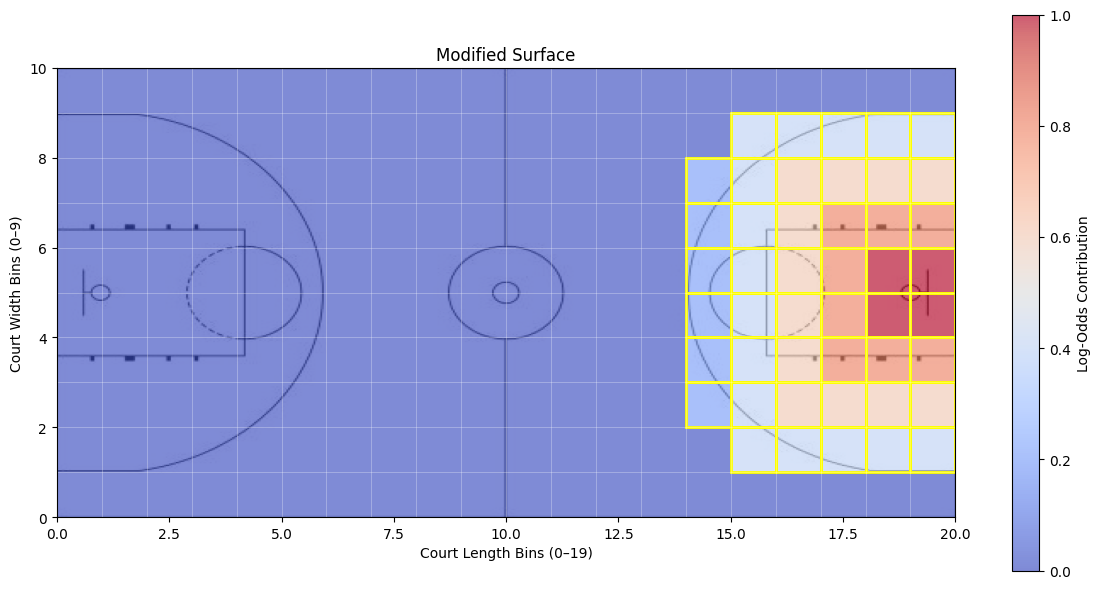

In [39]:
updates = {}

def wrap(x_1, x_2, y_1, y_2, val ,square):
    global modified_matrix

    updates.update(build_range_updates((x_1, x_1), (y_1, y_2), val))

    if (square == True): 
        updates.update(build_range_updates((x_2, x_2), (y_1, y_2), val))

    updates.update(build_range_updates((x_1, x_2), (y_1, y_1), val))
    updates.update(build_range_updates((x_1, x_2), (y_2, y_2), val))

    #return modified_matrix
    
updates.update(build_range_updates((18, 19), (4, 5), 1))
updates.update(build_range_updates((14, 14), (2, 7), .2))
wrap(17, 19, 3, 6, .8, False)
wrap(16, 19, 2, 7, .6, False)
wrap(15, 19, 1, 8, .4, False)

modified_matrix = adjust_sector_propensity(
    propensity_matrix,
    updates,
    mode="set"
    )

plot_surface(modified_matrix,
         "Modified Surface",
         changed=updates.keys())

In [41]:
df = pd.read_csv("multi_game_data.csv")

def build_visited_bin_matrices(df, x_bins=20, y_bins=10):
    required_cols = {"game_id", "possession_number", "x_bin", "y_bin", "scored"}
    missing_cols = required_cols.difference(df.columns)

    if missing_cols:
        raise ValueError(f"df is missing required columns: {sorted(missing_cols)}")

    records = []

    grouped = df.groupby(["game_id", "possession_number"], sort=True)
    for (game_id, possession_number), group in grouped:
        # Matrix shape is (x_bins, y_bins): x is the first axis, y is the second.
        visited_matrix = np.zeros((x_bins, y_bins), dtype=np.int8)
        visited_bins = set(zip(group["x_bin"].astype(int), group["y_bin"].astype(int)))

        for xb, yb in visited_bins:
            if 0 <= xb < x_bins and 0 <= yb < y_bins:
                visited_matrix[xb, yb] = 1

        records.append({
            "game_id": game_id,
            "possession_number": possession_number,
            "scored": int(group["scored"].iloc[0]),
            "visited_matrix": visited_matrix
        })

    return pd.DataFrame(records)


visited_bin_matrices = build_visited_bin_matrices(df, x_bins=x_bins, y_bins=y_bins)

# Shape: (n_possessions, x_bins, y_bins)
possession_game_bin_matrix = np.stack(visited_bin_matrices["visited_matrix"].to_numpy())

# Flatten each possession matrix into one design row while preserving x-by-y order.
X = possession_game_bin_matrix.reshape(len(visited_bin_matrices), -1)

# Outcome vector aligned with the stacked possession matrices and flattened design rows.
y = visited_bin_matrices["scored"].to_numpy(dtype=np.int8)

print("stacked matrix shape:", possession_game_bin_matrix.shape)
print("flattened design shape:", X.shape)
print("outcome shape:", y.shape)

X


stacked matrix shape: (902, 20, 10)
flattened design shape: (902, 200)
outcome shape: (902,)


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(902, 200), dtype=int8)

In [44]:
# Flatten betas in the same x-by-y order used to build each row of X.
betas = modified_matrix.reshape(-1)

if X.shape[1] != betas.shape[0]:
    raise ValueError(
        f"X has {X.shape[1]} columns but betas has length {betas.shape[0]}"
    )

logits = X @ betas
propensity_scores = 1 / (1 + np.exp(-logits))

print("X shape:", X.shape)
print("betas shape:", betas.shape)
print("logits shape:", logits.shape)
print("propensity_scores shape:", propensity_scores.shape)


In [45]:
betas

array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.4, 0.4, 0.4, 0.4,
       0.4, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0.2, 0.4, 0.6, 0.6, 0.6, 0.6, 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.2, 0.4, 0.6, 0.8,
       0.8, 0.8, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0.2, 0.4, 0.6, 0.8, 1. , 1. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.2, 0.4, 0.6,
       0.8, 1. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0.2, 0.4, 0.6, 0.8, 0.8, 0.8, 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.2, 0.4,
       0.6, 0.6, 0.6, 0.6, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0.4, 0.4, 0.4, 0.4, 0.4, 0.